<a href="https://colab.research.google.com/github/manasvitaral/IndianKidsScreenTIme-Analysis-Python/blob/main/IndianKidsScreenTime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/Indian_Kids_Screen_Time.csv")

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB
None


Univariate Analysis

Categorical Variables:
1. Gender Distribution:

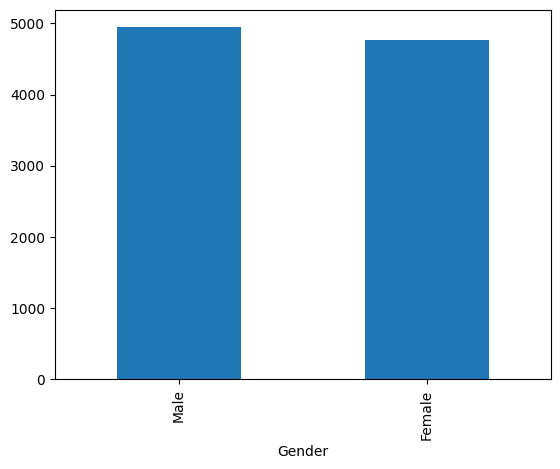

In [ ]:
df['Gender'].value_counts().plot(kind='bar')
plt.show()

2. Primary Device Usage:


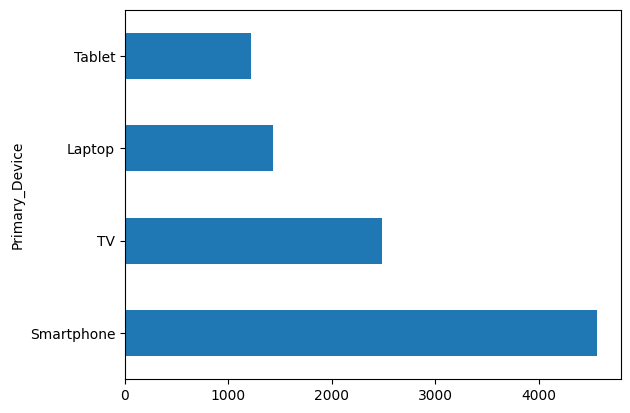

In [ ]:
#barh = horizontal bar chart
df['Primary_Device'].value_counts().plot(kind='barh')
plt.show()

3. Exceeded Recommended Limit:


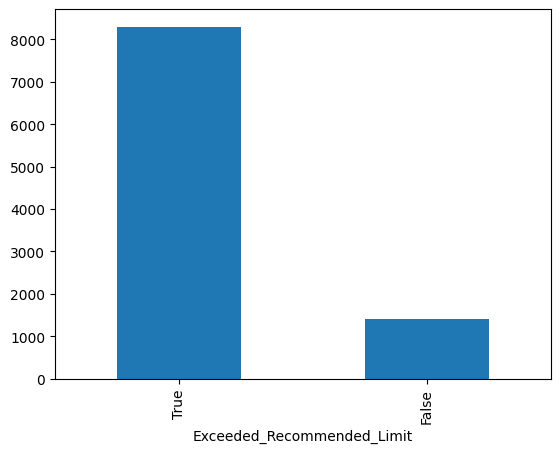

In [ ]:
df['Exceeded_Recommended_Limit'].value_counts().plot(kind='bar')
plt.show()

5. Health Impacts:


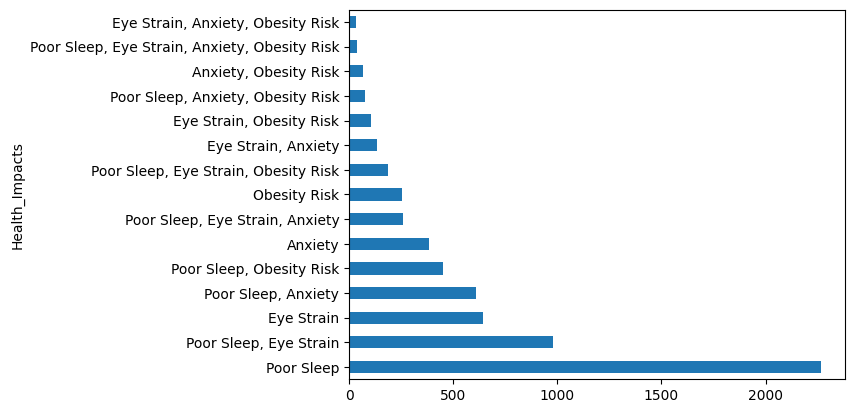

In [ ]:
df['Health_Impacts'].value_counts().plot(kind='barh')
plt.show()

Numerical Variables:
1. Age Distribution:

Range: 8 - 18
Mean: 12.979200988467875
Mode: 17


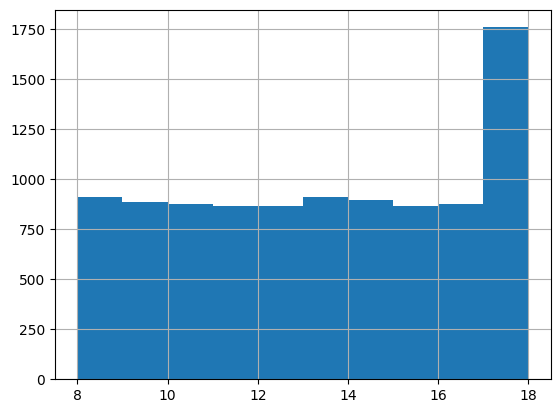

In [ ]:
# Range, Mean, Mode
print("Range:", df['Age'].min(), "-", df['Age'].max())
print("Mean:", df['Age'].mean())
print("Mode:", df['Age'].mode()[0])

# Histogram
df['Age'].hist()
plt.show()

2. Educational-Recreational Ratio:


Mean: 0.4272261120263592


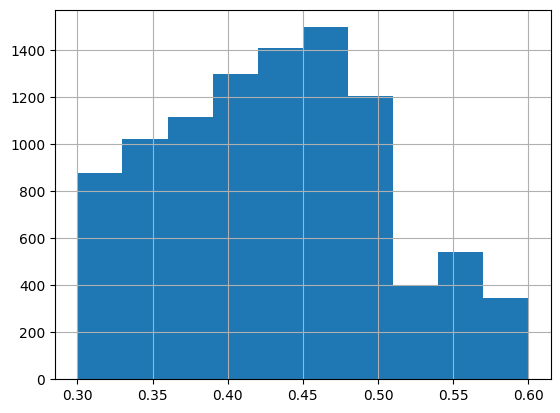

In [ ]:
# Mean
print("Mean:", df['Educational_to_Recreational_Ratio'].mean())

# Distribution (Histogram)
df['Educational_to_Recreational_Ratio'].hist()

plt.show()

Bivariate Analysis
1. Screen Time vs Age Groups:

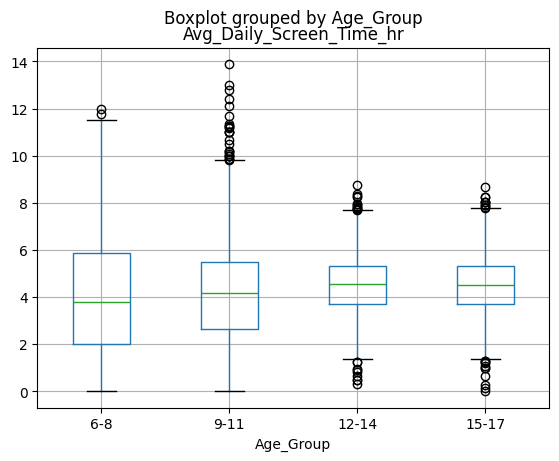

In [ ]:
#pd.cut() divides age into groups.
# Create age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[5,8,11,14,17], labels=['6-8','9-11','12-14','15-17'])

# Grouped boxplot
df.boxplot(column='Avg_Daily_Screen_Time_hr', by='Age_Group')

plt.show()

2. Screen Time vs Gender:

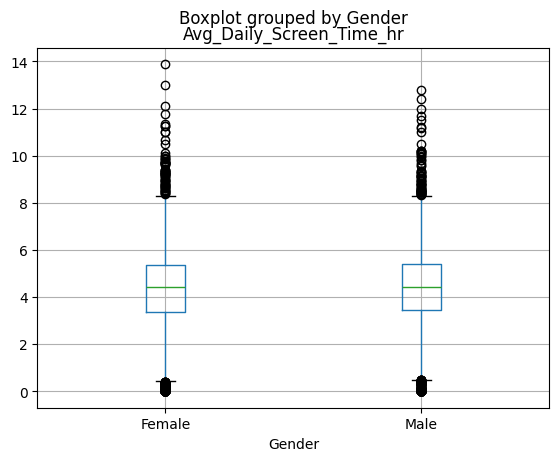

In [ ]:
#Shows screen time distribution for each gender.
df.boxplot(column='Avg_Daily_Screen_Time_hr', by='Gender')
plt.show()

3. Screen Time vs Location:


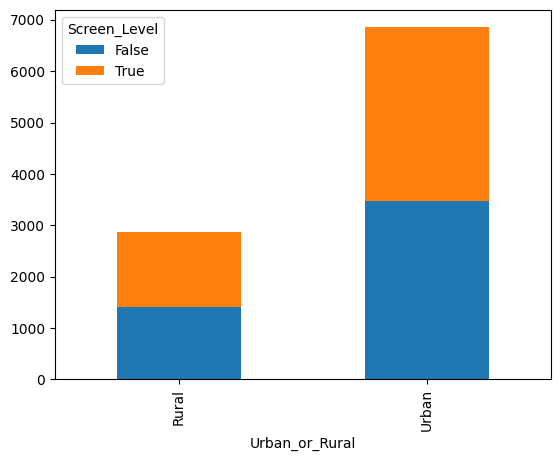

In [ ]:
#crosstab() makes table comparison
# Create High / Low screen time
df['Screen_Level'] = df['Avg_Daily_Screen_Time_hr'] > df['Avg_Daily_Screen_Time_hr'].median()

# Stacked bar
pd.crosstab(df['Urban_or_Rural'], df['Screen_Level']).plot(kind='bar', stacked=True)

plt.show()

4. Health Impacts vs Screen Time:

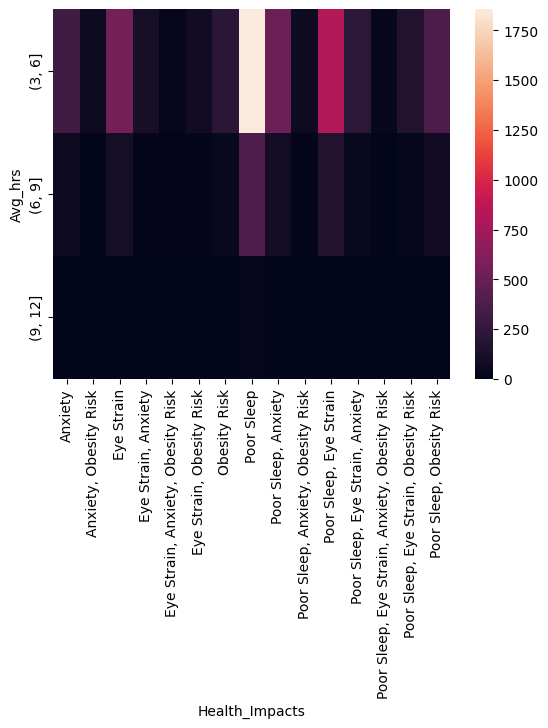

In [ ]:
df['Avg_hrs'] = pd.cut(df['Avg_Daily_Screen_Time_hr'], [0,3,6,9,12])
sns.heatmap(pd.crosstab(df['Avg_hrs'], df['Health_Impacts']))
plt.show()

5. Device Preference by Age:


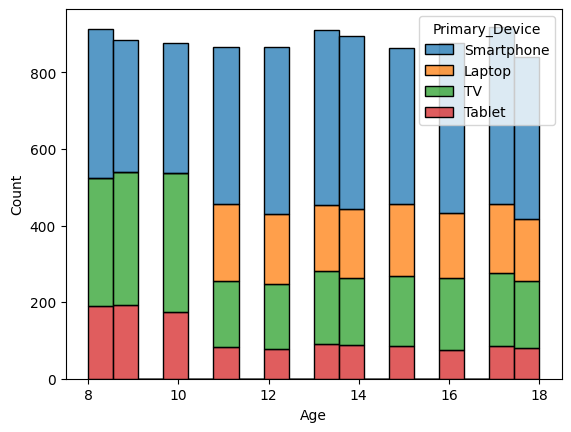

In [ ]:
sns.histplot(data=df, x="Age", hue="Primary_Device", multiple="stack")
plt.show()

6. Exceeded Limit by Device:


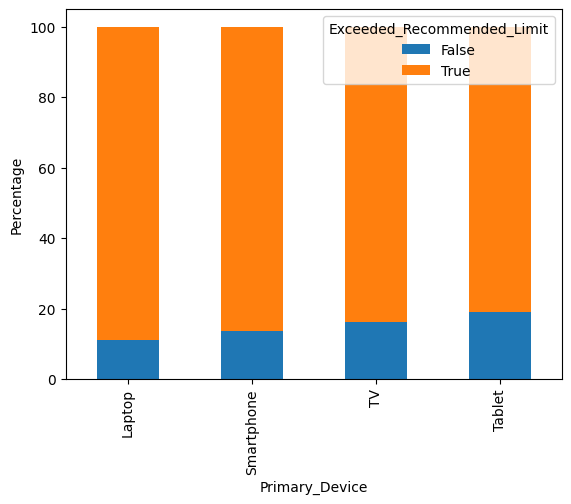

In [ ]:
#crosstab=It compares two categorical variables.
# Percentage table
t = pd.crosstab(df['Primary_Device'], df['Exceeded_Recommended_Limit'], normalize='index')*100

# 100% stacked bar
t.plot(kind='bar', stacked=True)

plt.ylabel("Percentage")
plt.show()

Multivariate Analysis
1. Age × Gender × Screen Time:

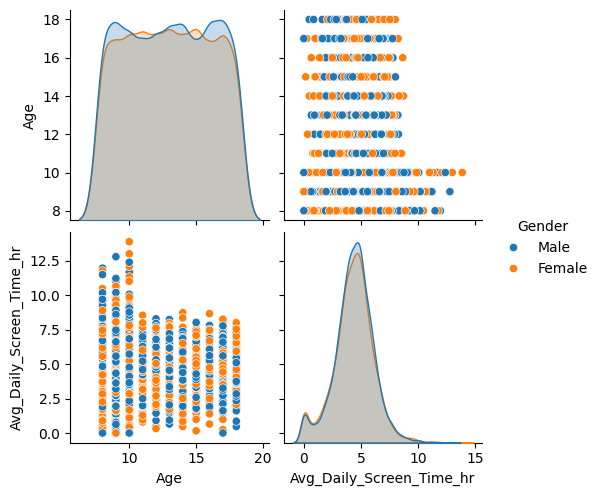

In [ ]:
sns.pairplot(df[['Age','Avg_Daily_Screen_Time_hr','Gender']], hue='Gender')

plt.show()

3. Correlation Matrix:


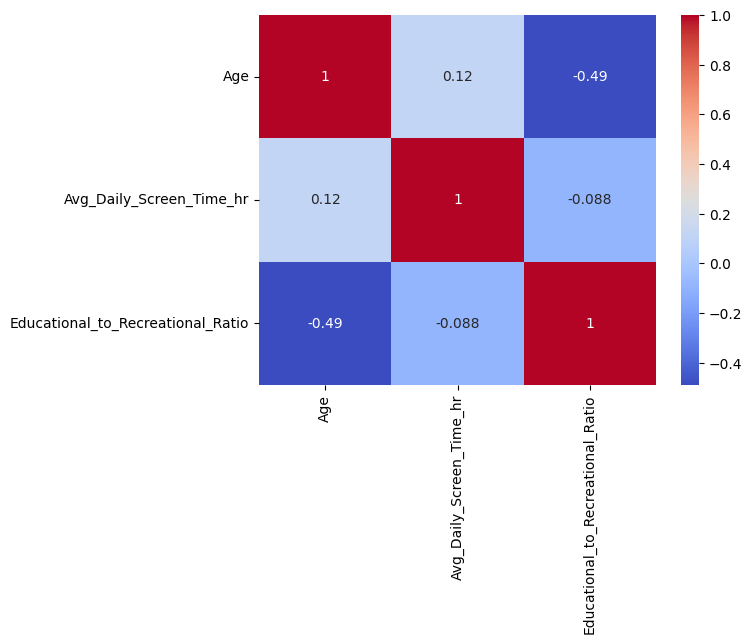

In [ ]:
# Compute correlation
corr = df[['Age', 'Avg_Daily_Screen_Time_hr', 'Educational_to_Recreational_Ratio']].corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
print(df.info())
